# EDA Plots: Genre vs. Top100

**Python port of `EDA_plots.R`.** Mosaic plot and stacked bar plot exploring the relationship between song genre and Billboard Top 100 inclusion.

`statsmodels`' `mosaic()` is the direct equivalent of R's `vcd::mosaic()`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
import os

DATA_DIR = 'data'
data = pd.read_csv(os.path.join(DATA_DIR, 'songs_complete_data.csv'), index_col=0)

## Mosaic Plot

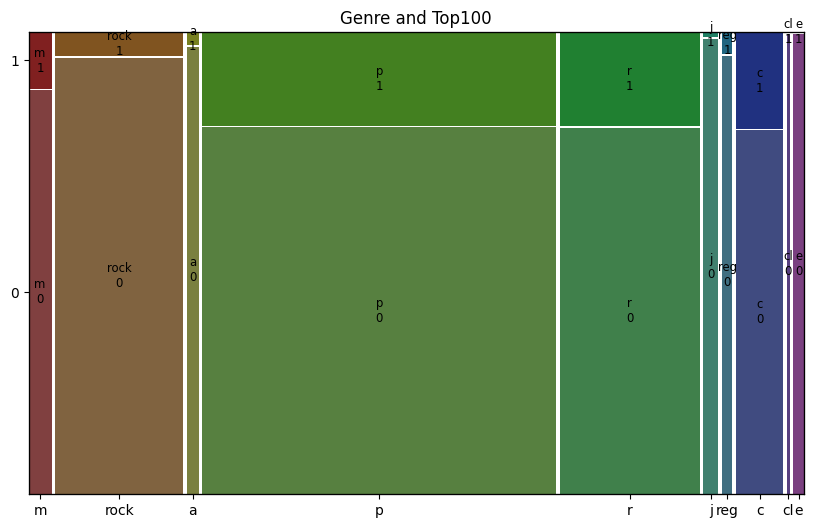

In [3]:
gen_codes = {
    'alternative': 'a', 'classical': 'cl', 'country': 'c', 'edm': 'e',
    'jazz': 'j', 'metal': 'm', 'pop': 'p', 'rap': 'r', 'reggae': 'reg', 'rock': 'rock'
}

plot_df = data[['Top100', 'Genre']].copy()
plot_df['Genre'] = plot_df['Genre'].map(gen_codes).fillna(plot_df['Genre'])

fig, ax = plt.subplots(figsize=(10, 6))
mosaic(plot_df, ['Genre', 'Top100'], ax=ax, title='Genre and Top100')
plt.show()

## Stacked Barplot

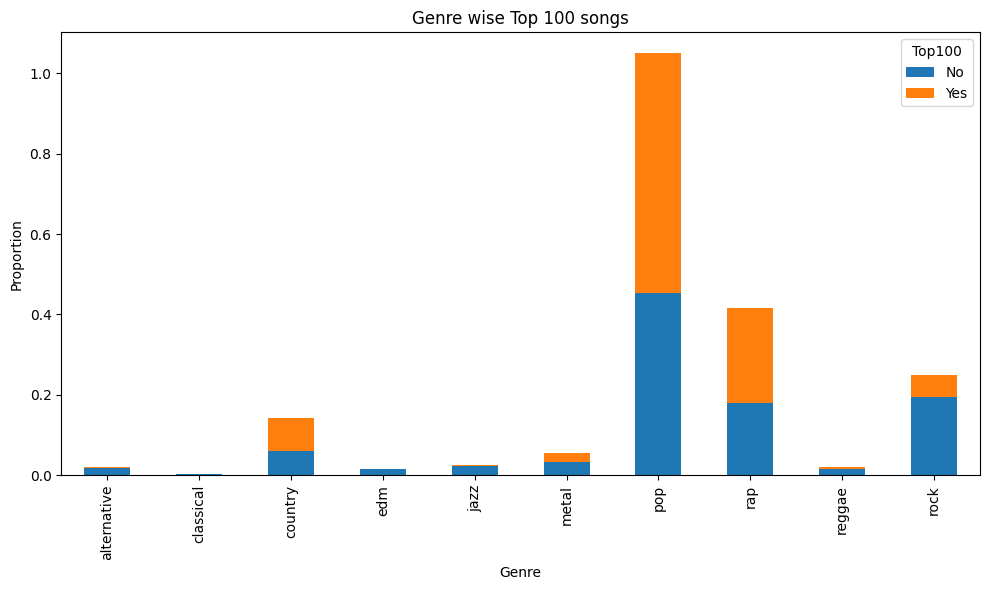

In [4]:
tab = pd.crosstab(data['Top100'], data['Genre'])
cond_genre = tab.div(tab.sum(axis=1), axis=0)  # conditional distribution within each Top100 value

cond_genre_df = cond_genre.reset_index().melt(id_vars='Top100', var_name='Genre', value_name='Proportion')

pivot = cond_genre_df.pivot(index='Genre', columns='Top100', values='Proportion').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Genre wise Top 100 songs')
ax.set_xlabel('Genre')
ax.set_ylabel('Proportion')
ax.legend(title='Top100', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()